# <center> Interpolación </center>

$ \newcommand{\mymatrix}[2]{\left[ \begin{array}{#1} #2\end{array} \right]} $

El problema es simple: **Tenemos un conjunto de puntos de datos y queremos encontrar una función que pase exactamente por todos ellos**.
<center>
<div>
<img src="https://staff.fnwi.uva.nl/r.vandenboomgaard/IPCV20162017/_images/cubicinterp.png" width="470"/>
</div>
</center>

Dados $n+1$ pares de puntos $(x_i, y_i)$, queremos encontrar una función $P(x)$ tal que

$$ P(x_i) = y_i $$

para cada $i = 0,...,n$.



## Polinomios de Lagrange

Construimos el polinomio $P_n(x)$ como una suma ponderada. Creamos una serie de _polinomios base_ $L_i(x)$, cada uno asociado a un punto $(x_i, y_i)$, que está diseñado para funcionar como un "interruptor":
* Vale 1 exactamente en $x_i$.
* Vale 0 en todos los demás puntos $x_j$ (con $j \neq i$).

y entonces lograr que el polinomio interpolante quede escrito como
$$ P_n(x) = \sum_{i=0}^n y_i L_i(x) $$

tal que
$$ L_i(x) = \prod_{\substack{j=0,\\ j \neq i}}^n \frac{x-x_j}{x_i - x_j} $$

In [ ]:
# i-ésimo polinomio base para el valor 'a'.
def L(a, i, xdata):
    Li = 1
    xi = xdata[i]
    for j, xj in enumerate(xdata):
        if i != j:
            Li *= (a - xj) / (xi - xj)
    return Li

# polinomio de Lagrange completo en el valor 'a'.
def PI(a, xdata, ydata):
    Pi = 0
    for i, yi in enumerate(ydata):
        Pi += yi * L(a, i, xdata)
    return Pi

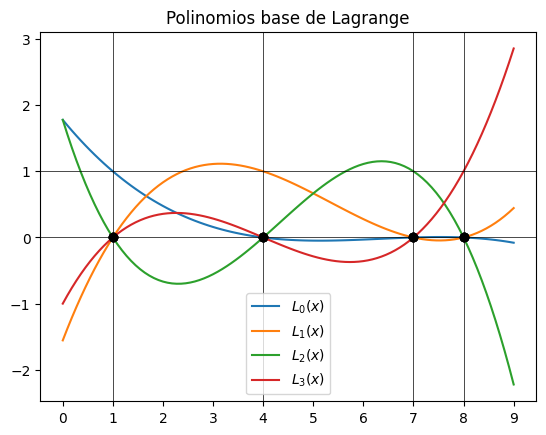

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

xdata = np.array([1, 4, 7, 8])
ts = np.linspace(0, 9, 100)

for i,x in enumerate(xdata):
    L_i = [L(t, i, xdata) for t in ts]
    plt.plot(ts, L_i, label=f'$L_{i}(x)$') # grafica los L_i(x)
    plt.plot(xdata, np.zeros_like(xdata), 'ko') # resalta los nodos

plt.title('Polinomios base de Lagrange')
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(1, color='black', linewidth=0.5)
for x in xdata:
    plt.axvline(x, color='black', linewidth=0.5)
ax = plt.gca()
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
plt.legend()
plt.show()